# Time Series Example
> # Tempreature Prediction

In [25]:
# load libs 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler

In [26]:
# load the dataset
data = pd.read_csv("1_Daily_minimum_temps.csv",parse_dates=True)
data.head()

,Date,Temp
0,01/01/81,20.7
1,01/02/81,17.9
2,01/03/81,18.8
3,01/04/81,14.6
4,01/05/81,15.8


> ## EDA

In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    3650 non-null   object
 1   Temp    3650 non-null   object
dtypes: object(2)
memory usage: 57.2+ KB


In [28]:
data["Temp"].unique()

array(['20.7', '17.9', '18.8', '14.6', '15.8', '17.4', '21.8', '20',
       '16.2', '13.3', '16.7', '21.5', '25', '20.6', '24.8', '17.7',
       '15.5', '18.2', '12.1', '14.4', '16', '16.5', '18.7', '19.4',
       '17.2', '15.1', '15.4', '15.3', '21.9', '19.9', '16.6', '16.8',
       '17.1', '15', '13.7', '13.9', '18.3', '22', '22.1', '21.2', '18.4',
       '16.1', '15.7', '18.5', '16.9', '17.5', '17.8', '18.6', '17',
       '14.3', '11.4', '16.3', '11.8', '12.2', '14.7', '11.3', '10.6',
       '11.7', '14.2', '11.2', '8.1', '8', '8.8', '13.4', '10.9', '11',
       '14.5', '18.1', '10', '14.9', '15.9', '13', '7.6', '11.5', '13.5',
       '12.4', '13.2', '13.8', '9', '9.8', '8.9', '7.4', '9.9', '9.3',
       '8.6', '11.9', '14', '12', '10.5', '10.7', '10.1', '5.3', '6.6',
       '8.5', '5.9', '3.2', '2.1', '3.4', '5.4', '9.6', '12.3', '12.6',
       '12.8', '11.6', '5.7', '7.1', '2.5', '3.5', '4.6', '7.7', '10.4',
       '9.2', '6.1', '2.7', '4.3', '6.3', '3.8', '4.4', '4.8', '5.8',
   

In [29]:
data[data["Temp"].str.startswith("?")]

,Date,Temp
565,07/20/82,?0.2
566,07/21/82,?0.8
1290,07/14/84,?0.1


In [30]:
data["Temp"] = pd.to_numeric(data["Temp"],errors="coerce")

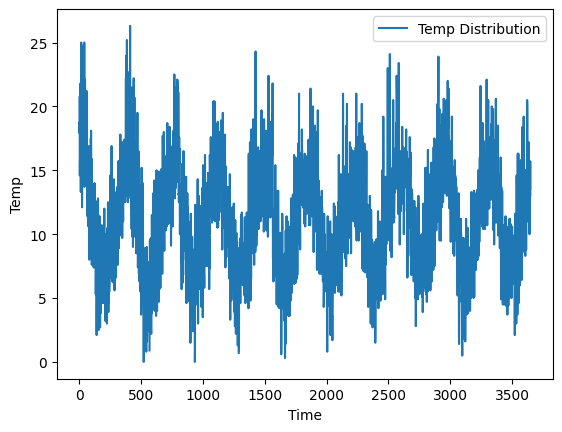

In [31]:
data["Temp"] = data["Temp"].astype("float32")
plt.Figure()
plt.plot(data["Temp"],label = "Temp Distribution")
plt.xlabel("Time")
plt.ylabel("Temp")
plt.legend()
plt.show()

In [32]:
data["Date"] = pd.to_datetime(data["Date"])

C:\Users\PC\AppData\Local\Temp\ipykernel_27288\2487158108.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data["Date"] = pd.to_datetime(data["Date"])


> ## Feature Extraction

In [33]:
data["DayofWeek"] = data["Date"].dt.day_of_week
data["Month"]  = data["Date"].dt.month
data["Year"] = data["Date"].dt.year

In [34]:
data.set_index("Date",inplace= True)

In [35]:
data.head()

,Temp,DayofWeek,Month,Year
Date,,,,
1981-01-01,20.700001,3,1,1981
1981-01-02,17.900000,4,1,1981
1981-01-03,18.799999,5,1,1981
1981-01-04,14.600000,6,1,1981
1981-01-05,15.800000,0,1,1981


In [36]:
data["Temp"] = data["Temp"].fillna(data["Temp"].mean())
data["Temp"].isnull().sum()

np.int64(0)

In [37]:
data["Year"].unique()

array([1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990],
      dtype=int32)

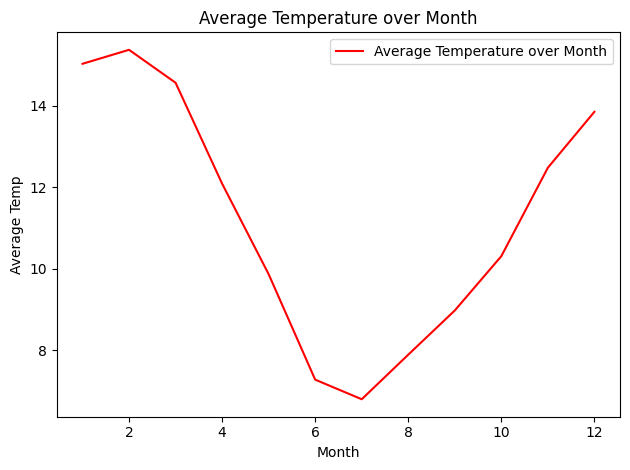

In [38]:
ave_temp_month = data.groupby("Month")["Temp"].agg("mean")
plt.plot(ave_temp_month,label = "Average Temperature over Month",c = "red")
plt.title("Average Temperature over Month")
plt.xlabel("Month")
plt.ylabel("Average Temp")
plt.legend()
plt.tight_layout()
plt.show()

In [39]:
ave_temp_year = data.groupby("Year")["Temp"].agg(("mean","max","min")).reset_index()
ave_temp_year

,Year,mean,max,min
0,1981,11.517260,25.000000,2.1
1,1982,10.842118,26.299999,0.0
2,1983,11.187397,22.500000,0.0
3,1984,10.622155,24.299999,0.7
4,1985,11.137534,22.400000,0.3
5,1986,10.803288,21.400000,0.8
6,1987,10.853150,24.100000,1.5
7,1988,11.972054,23.900000,2.8
8,1989,11.261918,22.000000,0.5
9,1990,11.669589,22.100000,2.1


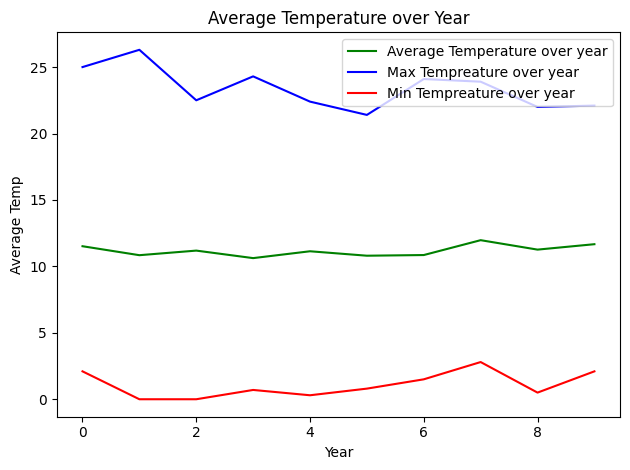

In [40]:
plt.plot(ave_temp_year["mean"],label = "Average Temperature over year",c = "green")
plt.plot(ave_temp_year["max"],label = "Max Tempreature over year",c = "blue")
plt.plot(ave_temp_year["min"],label = "Min Tempreature over year",c = "red")
plt.title("Average Temperature over Year")
plt.xlabel("Year")
plt.ylabel("Average Temp")
plt.legend()
plt.tight_layout()
plt.show()

> ## Preprocessing and Window Slicing

In [41]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3650 entries, 1981-01-01 to 1990-12-31
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Temp       3650 non-null   float32
 1   DayofWeek  3650 non-null   int32  
 2   Month      3650 non-null   int32  
 3   Year       3650 non-null   int32  
dtypes: float32(1), int32(3)
memory usage: 85.5 KB


In [42]:
features = ["DayofWeek","Month","Year"]
target = ["Temp"]
data = data.dropna()
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_x.fit_transform(data[features])
y_scaled = scaler_y.fit_transform(data[target])

In [50]:
def create_seq(X_data, y_data, seq_len):
    X_out, y_out = [], []

    for i in range(len(X_data) - seq_len):
        X_out.append(X_data[i : i + seq_len])
        y_out.append(y_data[i + seq_len])

    return np.array(X_out), np.array(y_out)

In [51]:
seq_len = 7 # 7 days
X,y = create_seq(X_scaled,y_scaled,seq_len)

In [52]:
X,y

(array([[[0.5       , 0.        , 0.        ],
         [0.66666667, 0.        , 0.        ],
         [0.83333333, 0.        , 0.        ],
         ...,
         [0.        , 0.        , 0.        ],
         [0.16666667, 0.        , 0.        ],
         [0.33333333, 0.        , 0.        ]],
 
        [[0.66666667, 0.        , 0.        ],
         [0.83333333, 0.        , 0.        ],
         [1.        , 0.        , 0.        ],
         ...,
         [0.16666667, 0.        , 0.        ],
         [0.33333333, 0.        , 0.        ],
         [0.5       , 0.        , 0.        ]],
 
        [[0.83333333, 0.        , 0.        ],
         [1.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ],
         ...,
         [0.33333333, 0.        , 0.        ],
         [0.5       , 0.        , 0.        ],
         [0.66666667, 0.        , 0.        ]],
 
        ...,
 
        [[0.83333333, 1.        , 1.        ],
         [1.        , 1.        , 1.     

In [53]:
split_rate = int(len(X)*0.8)
X_train = X[:split_rate]
X_test = X[split_rate:]
y_train = y[:split_rate]
y_test = y[split_rate]
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((2914, 7, 3), (729, 7, 3), (2914, 1), (1,))

In [58]:
# LSTM Model and GRU model
model_lstm = tf.keras.Sequential([
    tf.keras.layers.LSTM(64,activation="tanh"),
    tf.keras.layers.Dense(1)
])

model_lstm.compile(loss = "MeanAbsoluteError",
                   optimizer = tf.keras.optimizers.Adam(),
                   metrics = ["mae"])

history= model_lstm.fit(X_train,y_train,epochs = 25)

Epoch 1/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1389 - mae: 0.1389
Epoch 2/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1094 - mae: 0.1094
Epoch 3/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0991 - mae: 0.0991
Epoch 4/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0962 - mae: 0.0962
Epoch 5/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0925 - mae: 0.0925
Epoch 6/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0917 - mae: 0.0917
Epoch 7/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0907 - mae: 0.0907
Epoch 8/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0903 - mae: 0.0903
Epoch 9/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0897 - mae: 0.0897
Epoch 10/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0893 - mae: 0.0893
Epoch 11/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0887 - mae: 0.0887
Epoch 12/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0906 - mae: 0.0906
Epoch 13/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/ste

<Axes: >

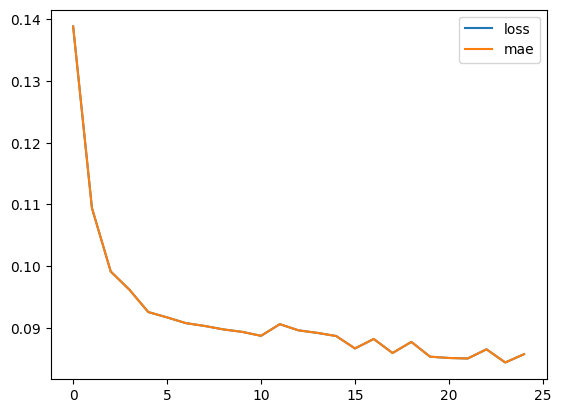

In [60]:
pd.DataFrame(history.history).plot()

In [59]:
model_lstm.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 64)             │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,421 (204.77 KB)

 Trainable params: 17,473 (68.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 34,948 (136.52 KB)

In [61]:
model_gru = tf.keras.Sequential([
    tf.keras.layers.GRU(64,activation="tanh"),
    tf.keras.layers.Dense(1)
])

model_gru.compile(loss = tf.keras.losses.MeanAbsoluteError(),
                  optimizer = tf.keras.optimizers.Adam(),
                  metrics  = ["mae"])

history_gru = model_gru.fit(X_train,y_train,epochs = 25)

model_gru.summary()

Epoch 1/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.1519 - mae: 0.1519
Epoch 2/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1196 - mae: 0.1196
Epoch 3/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1184 - mae: 0.1184
Epoch 4/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1049 - mae: 0.1049
Epoch 5/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0913 - mae: 0.0913
Epoch 6/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0904 - mae: 0.0904
Epoch 7/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0905 - mae: 0.0905
Epoch 8/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0902 - mae: 0.0902
Epoch 9/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0887 - mae: 0.0887
Epoch 10/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0886 - mae: 0.0886
Epoch 11/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0891 - mae: 0.0891
Epoch 12/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0897 - mae: 0.0897
Epoch 13/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/ste

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        13,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,941 (156.02 KB)

 Trainable params: 13,313 (52.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 26,628 (104.02 KB)

<Axes: >

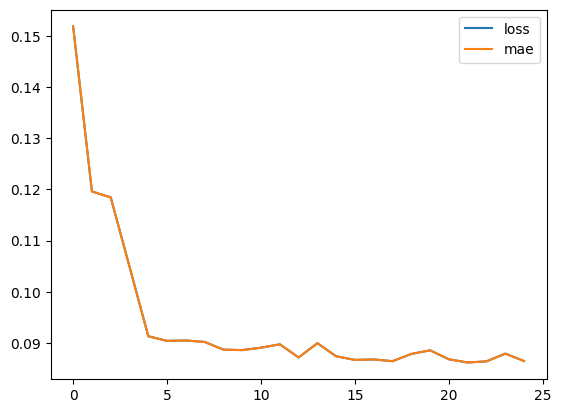

In [62]:
pd.DataFrame(history_gru.history).plot()

In [72]:
lstm_preds = model_lstm.predict(X_test)
gru_preds = model_gru.predict(X_test)

from sklearn.metrics import mean_absolute_error,root_mean_squared_error

gru_preds = gru_preds.reshape(1,-1)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [75]:
y_test_true = y_test.reshape(1,-1)

In [78]:
lstm_preds = lstm_preds.reshape(1,-1)
lstm_preds

array([[0.5236995 , 0.50304204, 0.47974303, 0.4576297 , 0.46793166,
        0.55314964, 0.5964674 , 0.6101625 , 0.5618874 , 0.5673887 ,
        0.571507  , 0.5771591 , 0.5854338 , 0.5964674 , 0.6101625 ,
        0.5618874 , 0.5673887 , 0.571507  , 0.5771591 , 0.5854338 ,
        0.5964674 , 0.6101625 , 0.5618874 , 0.5673887 , 0.571507  ,
        0.5771591 , 0.5854338 , 0.5964674 , 0.6101625 , 0.5618874 ,
        0.5673887 , 0.5681986 , 0.5713075 , 0.57715106, 0.5851806 ,
        0.5944166 , 0.5513607 , 0.5579198 , 0.56234044, 0.5670039 ,
        0.5731308 , 0.5809458 , 0.5899686 , 0.5505099 , 0.5579198 ,
        0.56234044, 0.5670039 , 0.5731308 , 0.5809458 , 0.5899686 ,
        0.5505099 , 0.5579198 , 0.56234044, 0.5670039 , 0.5731308 ,
        0.5809458 , 0.5899686 , 0.5505099 , 0.5579198 , 0.5580788 ,
        0.55878586, 0.560802  , 0.56352913, 0.5653068 , 0.5291606 ,
        0.5348973 , 0.5399097 , 0.54353553, 0.5472069 , 0.5512119 ,
        0.5546388 , 0.5249705 , 0.5348973 , 0.53